### Datensatz aus Pickle-Datei laden

In [1]:
import pandas as pd

# Pfad zur PKL-Datei
pkl_file = '../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl'

# PKL-Datei einlesen
print(f"Lese PKL-Datei: {pkl_file}")
df_loaded = pd.read_pickle(pkl_file)

# Informationen über den DataFrame anzeigen
print(f"\nDataFrame Shape: {df_loaded.shape}")
print(f"Spalten: {df_loaded.columns.tolist()}")
print(f"\nErste Zeilen:")
print(df_loaded.head())

Lese PKL-Datei: ../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl

DataFrame Shape: (200000, 24)
Spalten: ['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']

Erste Zeilen:
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43

In [2]:
# Bibliotheken für Visualisierungen importieren
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Visualisierungs-Bibliotheken geladen")

✓ Visualisierungs-Bibliotheken geladen


## 1. Grundlegende Datenübersicht

Überblick über die Struktur und Qualität des Datensatzes.

In [ ]:
# Allgemeine Informationen
print("=" * 80)
print("DATENSATZ-ÜBERSICHT")
print("=" * 80)
print(f"\nAnzahl der Transaktionen: {len(df_loaded):,}")
print(f"Anzahl der Features: {len(df_loaded.columns)}")
print(f"\nDatentypen der Spalten:")
print(df_loaded.dtypes)

DATENSATZ-ÜBERSICHT

Anzahl der Transaktionen: 200,000
Anzahl der Features: 24

Datentypen der Spalten:
Customer_ID                 object
Customer_Name               object
Gender                      object
Age                          int64
State                       object
City                        object
Bank_Branch                 object
Account_Type                object
Transaction_ID              object
Transaction_Date            object
Transaction_Time            object
Transaction_Amount         float64
Merchant_ID                 object
Transaction_Type            object
Merchant_Category           object
Account_Balance            float64
Transaction_Device          object
Transaction_Location        object
Device_Type                 object
Is_Fraud                     int64
Transaction_Currency        object
Customer_Contact            object
Transaction_Description     object
Customer_Email              object
dtype: object

Speicherverbrauch:
249.53881168365479 MB


In [ ]:
# Fehlende Werte analysieren
print("=" * 80)
print("FEHLENDE WERTE")
print("=" * 80)
missing_values = df_loaded.isnull().sum()
missing_percent = (missing_values / len(df_loaded)) * 100
missing_df = pd.DataFrame({
    'Fehlende Werte': missing_values,
    'Prozent': missing_percent
})
missing_df = missing_df[missing_df['Fehlende Werte'] > 0].sort_values('Fehlende Werte', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("Keine fehlenden Werte im Datensatz!")

FEHLENDE WERTE

✓ Keine fehlenden Werte im Datensatz!


In [5]:
# Duplikate prüfen
print("=" * 80)
print("DUPLIKATE")
print("=" * 80)
duplicates = df_loaded.duplicated().sum()
print(f"\nAnzahl duplizierter Zeilen: {duplicates:,}")

# Transaction_ID sollte eindeutig sein
duplicate_transactions = df_loaded['Transaction_ID'].duplicated().sum()
print(f"Duplizierte Transaction_IDs: {duplicate_transactions:,}")

# Customer_ID Duplikate (Kunden können mehrere Transaktionen haben)
duplicate_customers = df_loaded['Customer_ID'].duplicated().sum()
unique_customers = df_loaded['Customer_ID'].nunique()
print(f"\nEindeutige Kunden: {unique_customers:,}")
print(f"Transaktionen von wiederkehrenden Kunden: {duplicate_customers:,}")

DUPLIKATE



Anzahl duplizierter Zeilen: 0
Duplizierte Transaction_IDs: 0

Eindeutige Kunden: 200,000
Transaktionen von wiederkehrenden Kunden: 0


## 2. Zielvariable: Fraud-Verteilung

Die wichtigste Variable für die Betrugserkennung.

In [6]:
# Fraud-Verteilung
print("=" * 80)
print("FRAUD-VERTEILUNG")
print("=" * 80)
fraud_counts = df_loaded['Is_Fraud'].value_counts()
fraud_percent = df_loaded['Is_Fraud'].value_counts(normalize=True) * 100

print(f"\nAbsolute Zahlen:")
print(fraud_counts)
print(f"\nProzentuale Verteilung:")
for idx, val in fraud_percent.items():
    label = "Betrug" if idx == 1 else "Legitim"
    print(f"{label} (Is_Fraud={idx}): {val:.2f}%")
    
# Klassenungleichgewicht berechnen
fraud_ratio = fraud_counts[0] / fraud_counts[1] if 1 in fraud_counts else 0
print(f"\nKlassen-Ratio (Legitim:Betrug) = {fraud_ratio:.2f}:1")

FRAUD-VERTEILUNG

Absolute Zahlen:
Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

Prozentuale Verteilung:
Legitim (Is_Fraud=0): 94.96%
Betrug (Is_Fraud=1): 5.04%

Klassen-Ratio (Legitim:Betrug) = 18.83:1


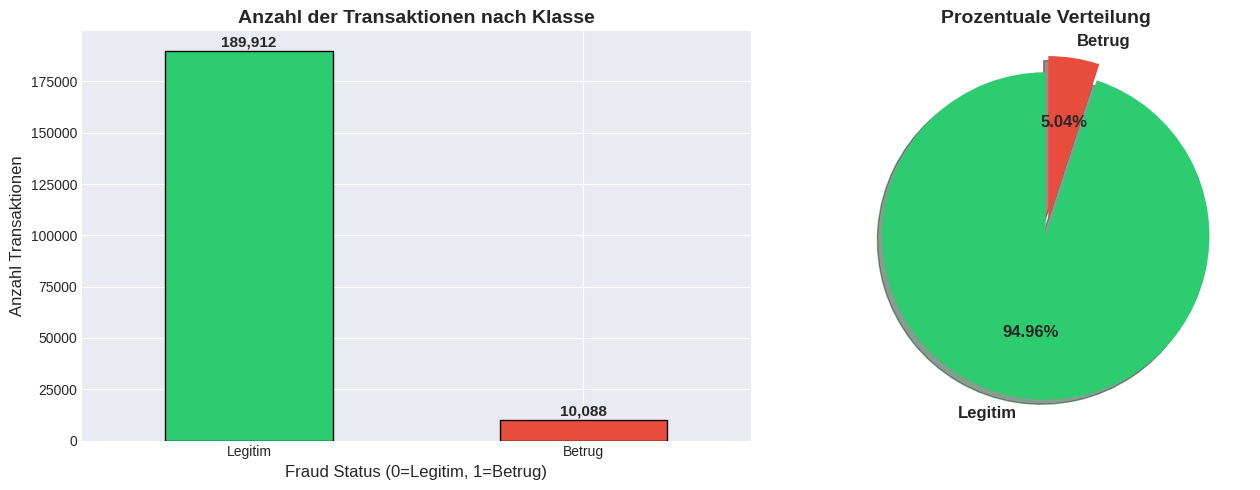


Klassenungleichgewicht: 18.83:1


In [29]:
# Visualisierung der Fraud-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm
colors = ['#2ecc71', '#e74c3c']
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Anzahl der Transaktionen nach Klasse', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fraud Status (0=Legitim, 1=Betrug)', fontsize=12)
axes[0].set_ylabel('Anzahl Transaktionen', fontsize=12)
axes[0].set_xticklabels(['Legitim', 'Betrug'], rotation=0)
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Kuchendiagramm
axes[1].pie(fraud_counts, labels=['Legitim', 'Betrug'], autopct='%1.2f%%', 
            colors=colors, startangle=90, explode=(0, 0.1), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Prozentuale Verteilung', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKlassenungleichgewicht: {fraud_counts[0]/fraud_counts[1]:.2f}:1")

## 3. Numerische Features

Analyse der numerischen Variablen.

In [8]:
# Numerische Spalten identifizieren
numeric_cols = df_loaded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=" * 80)
print("NUMERISCHE FEATURES")
print("=" * 80)
print(f"\nNumerische Spalten: {numeric_cols}")
print(f"\nStatistische Kennzahlen:\n")
print(df_loaded[numeric_cols].describe())

NUMERISCHE FEATURES

Numerische Spalten: ['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud']

Statistische Kennzahlen:

                 Age  Transaction_Amount  Account_Balance       Is_Fraud
count  200000.000000       200000.000000    200000.000000  200000.000000
mean       44.015110        49538.015554     52437.988784       0.050440
std        15.288774        28551.874004     27399.507128       0.218852
min        18.000000           10.290000      5000.820000       0.000000
25%        31.000000        24851.345000     28742.395000       0.000000
50%        44.000000        49502.440000     52372.555000       0.000000
75%        57.000000        74314.625000     76147.670000       0.000000
max        70.000000        98999.980000     99999.950000       1.000000


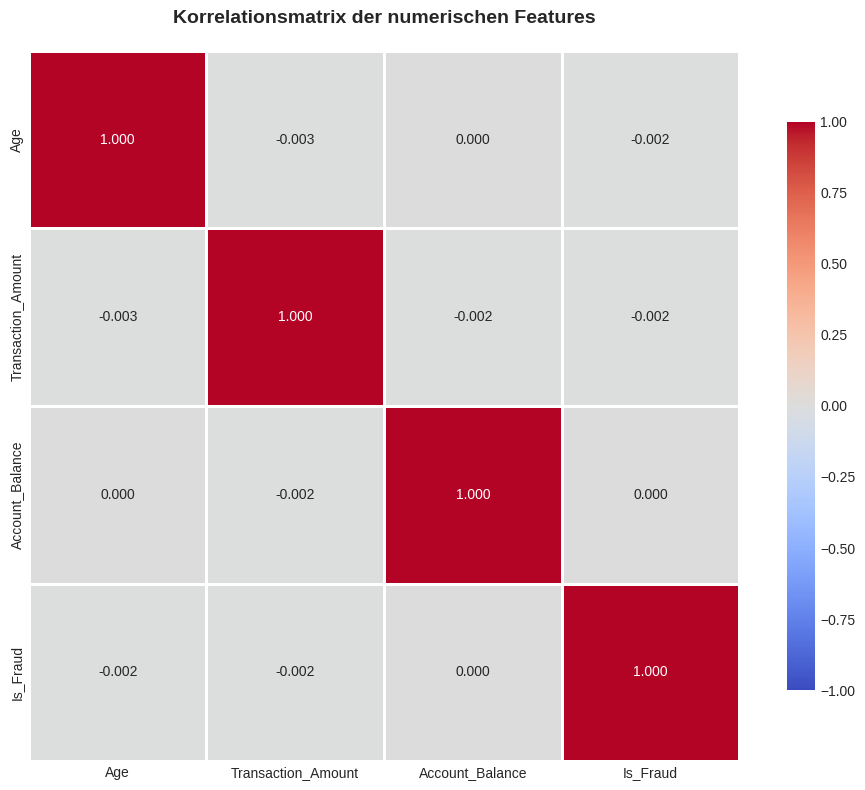


💡 Interpretation: Werte nahe 1 oder -1 zeigen starke Korrelationen


In [ ]:
# Korrelationsmatrix der numerischen Features
correlation_matrix = df_loaded[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Korrelationsmatrix der numerischen Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [10]:
# Detaillierte Analyse der Transaktionsbeträge
print("=" * 80)
print("TRANSAKTIONSBETRÄGE (Transaction_Amount)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Transaction_Amount'].mean():.2f} INR")
print(f"Median: {df_loaded['Transaction_Amount'].median():.2f} INR")
print(f"Standardabweichung: {df_loaded['Transaction_Amount'].std():.2f} INR")
print(f"Minimum: {df_loaded['Transaction_Amount'].min():.2f} INR")
print(f"Maximum: {df_loaded['Transaction_Amount'].max():.2f} INR")

# Quartile
print(f"\nQuartile:")
print(f"25%: {df_loaded['Transaction_Amount'].quantile(0.25):.2f} INR")
print(f"75%: {df_loaded['Transaction_Amount'].quantile(0.75):.2f} INR")
print(f"90%: {df_loaded['Transaction_Amount'].quantile(0.90):.2f} INR")
print(f"95%: {df_loaded['Transaction_Amount'].quantile(0.95):.2f} INR")
print(f"99%: {df_loaded['Transaction_Amount'].quantile(0.99):.2f} INR")

TRANSAKTIONSBETRÄGE (Transaction_Amount)

Mittelwert: 49538.02 INR
Median: 49502.44 INR
Standardabweichung: 28551.87 INR
Minimum: 10.29 INR
Maximum: 98999.98 INR

Quartile:
25%: 24851.34 INR
75%: 74314.62 INR
90%: 89135.39 INR
95%: 93992.85 INR
99%: 97989.52 INR


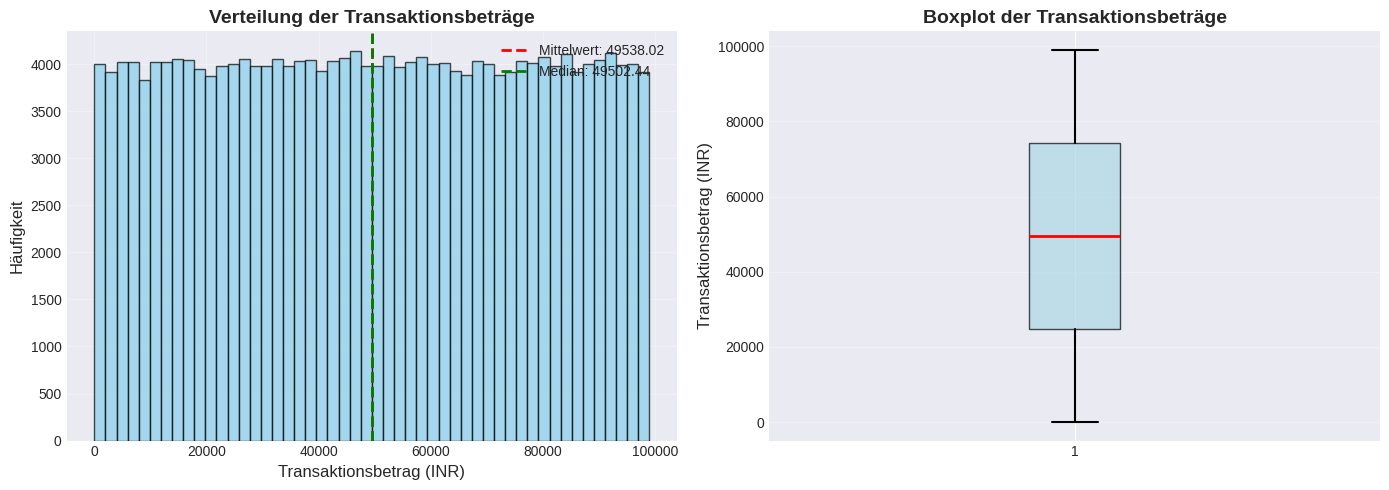

In [11]:
# Visualisierung der Transaktionsbeträge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm
axes[0].hist(df_loaded['Transaction_Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_loaded['Transaction_Amount'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {df_loaded["Transaction_Amount"].mean():.2f}')
axes[0].axvline(df_loaded['Transaction_Amount'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_loaded["Transaction_Amount"].median():.2f}')
axes[0].set_title('Verteilung der Transaktionsbeträge', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaktionsbetrag (INR)', fontsize=12)
axes[0].set_ylabel('Häufigkeit', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df_loaded['Transaction_Amount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
axes[1].set_title('Boxplot der Transaktionsbeträge', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transaktionsbetrag (INR)', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [12]:
# Kontostand-Analyse
print("=" * 80)
print("KONTOSTAND (Account_Balance)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Account_Balance'].mean():.2f} INR")
print(f"Median: {df_loaded['Account_Balance'].median():.2f} INR")
print(f"Standardabweichung: {df_loaded['Account_Balance'].std():.2f} INR")
print(f"Minimum: {df_loaded['Account_Balance'].min():.2f} INR")
print(f"Maximum: {df_loaded['Account_Balance'].max():.2f} INR")

# Negative Kontostände?
negative_balances = (df_loaded['Account_Balance'] < 0).sum()
print(f"\nKonten mit negativem Kontostand: {negative_balances:,}")

KONTOSTAND (Account_Balance)

Mittelwert: 52437.99 INR
Median: 52372.56 INR
Standardabweichung: 27399.51 INR
Minimum: 5000.82 INR
Maximum: 99999.95 INR

Konten mit negativem Kontostand: 0


In [13]:
# Altersverteilung
print("=" * 80)
print("ALTERSVERTEILUNG (Age)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Age'].mean():.1f} Jahre")
print(f"Median: {df_loaded['Age'].median():.1f} Jahre")
print(f"Standardabweichung: {df_loaded['Age'].std():.1f} Jahre")
print(f"Minimum: {df_loaded['Age'].min()} Jahre")
print(f"Maximum: {df_loaded['Age'].max()} Jahre")

# Altersgruppen
age_bins = [0, 18, 30, 40, 50, 60, 100]
age_labels = ['<18', '18-30', '31-40', '41-50', '51-60', '60+']
age_groups = pd.cut(df_loaded['Age'], bins=age_bins, labels=age_labels, right=False)
print(f"\nVerteilung nach Altersgruppen:")
print(age_groups.value_counts().sort_index())

ALTERSVERTEILUNG (Age)

Mittelwert: 44.0 Jahre
Median: 44.0 Jahre
Standardabweichung: 15.3 Jahre
Minimum: 18 Jahre
Maximum: 70 Jahre

Verteilung nach Altersgruppen:
Age
<18          0
18-30    45092
31-40    37948
41-50    37692
51-60    37636
60+      41632
Name: count, dtype: int64


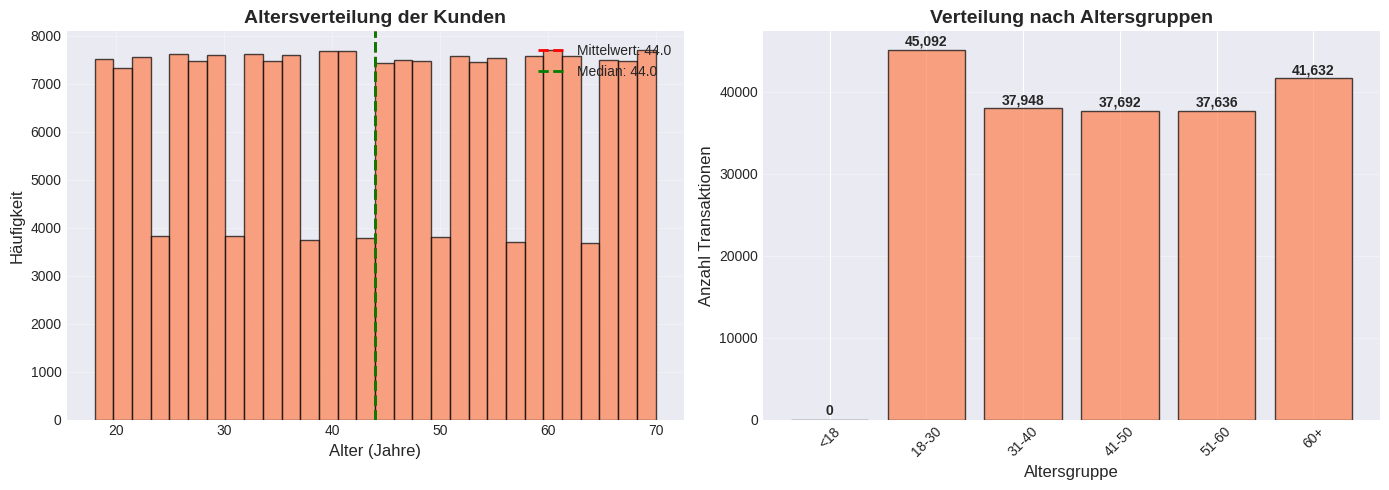

In [14]:
# Visualisierung der Altersverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm
axes[0].hist(df_loaded['Age'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df_loaded['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {df_loaded["Age"].mean():.1f}')
axes[0].axvline(df_loaded['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_loaded["Age"].median():.1f}')
axes[0].set_title('Altersverteilung der Kunden', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Alter (Jahre)', fontsize=12)
axes[0].set_ylabel('Häufigkeit', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Balkendiagramm nach Altersgruppen
age_groups_counts = age_groups.value_counts().sort_index()
axes[1].bar(range(len(age_groups_counts)), age_groups_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(age_groups_counts)))
axes[1].set_xticklabels(age_groups_counts.index, rotation=45)
axes[1].set_title('Verteilung nach Altersgruppen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Altersgruppe', fontsize=12)
axes[1].set_ylabel('Anzahl Transaktionen', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

# Werte auf Balken anzeigen
for i, v in enumerate(age_groups_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Kategorische Features

Analyse der kategorialen Variablen und deren Verteilung.

In [15]:
# Kategorische Spalten identifizieren
categorical_cols = df_loaded.select_dtypes(include=['object']).columns.tolist()
print("=" * 80)
print("KATEGORISCHE FEATURES")
print("=" * 80)
print(f"\nAnzahl kategorialer Spalten: {len(categorical_cols)}\n")

# Für jede kategorische Spalte die Anzahl eindeutiger Werte zeigen
for col in categorical_cols:
    unique_count = df_loaded[col].nunique()
    print(f"{col:30s}: {unique_count:6,} eindeutige Werte")

KATEGORISCHE FEATURES

Anzahl kategorialer Spalten: 20

Customer_ID                   : 200,000 eindeutige Werte
Customer_Name                 : 142,699 eindeutige Werte
Gender                        :      2 eindeutige Werte
State                         :     34 eindeutige Werte
City                          :    145 eindeutige Werte
Bank_Branch                   :    145 eindeutige Werte
Account_Type                  :      3 eindeutige Werte
Transaction_ID                : 200,000 eindeutige Werte
Transaction_Date              :     31 eindeutige Werte
Transaction_Time              : 77,856 eindeutige Werte
Merchant_ID                   : 200,000 eindeutige Werte
Transaction_Type              :      5 eindeutige Werte
Merchant_Category             :      6 eindeutige Werte
Transaction_Device            :     20 eindeutige Werte
Transaction_Location          :    148 eindeutige Werte
Device_Type                   :      4 eindeutige Werte
Transaction_Currency          :      1 einde

In [16]:
# Top-Werte für wichtige kategorische Features
important_cat_features = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                          'Transaction_Device', 'Device_Type', 'Transaction_Currency']

for feature in important_cat_features:
    if feature in df_loaded.columns:
        print("=" * 80)
        print(f"{feature.upper()}")
        print("=" * 80)
        value_counts = df_loaded[feature].value_counts()
        value_percent = df_loaded[feature].value_counts(normalize=True) * 100
        
        print(f"\nAnzahl eindeutiger Werte: {df_loaded[feature].nunique()}")
        print(f"\nTop 10 Werte:")
        for idx, (val, count) in enumerate(value_counts.head(10).items(), 1):
            print(f"  {idx:2d}. {str(val):30s}: {count:7,} ({value_percent[val]:5.2f}%)")
        print()

GENDER

Anzahl eindeutiger Werte: 2

Top 10 Werte:
   1. Male                          : 100,452 (50.23%)
   2. Female                        :  99,548 (49.77%)

ACCOUNT_TYPE

Anzahl eindeutiger Werte: 3

Top 10 Werte:
   1. Checking                      :  66,924 (33.46%)
   2. Savings                       :  66,593 (33.30%)
   3. Business                      :  66,483 (33.24%)

TRANSACTION_TYPE

Anzahl eindeutiger Werte: 5

Top 10 Werte:
   1. Credit                        :  40,180 (20.09%)
   2. Debit                         :  40,050 (20.03%)
   3. Bill Payment                  :  40,040 (20.02%)
   4. Transfer                      :  39,953 (19.98%)
   5. Withdrawal                    :  39,777 (19.89%)

MERCHANT_CATEGORY

Anzahl eindeutiger Werte: 6

Top 10 Werte:
   1. Restaurant                    :  33,525 (16.76%)
   2. Entertainment                 :  33,421 (16.71%)
   3. Electronics                   :  33,409 (16.70%)
   4. Clothing                      :  33,340 (16.6

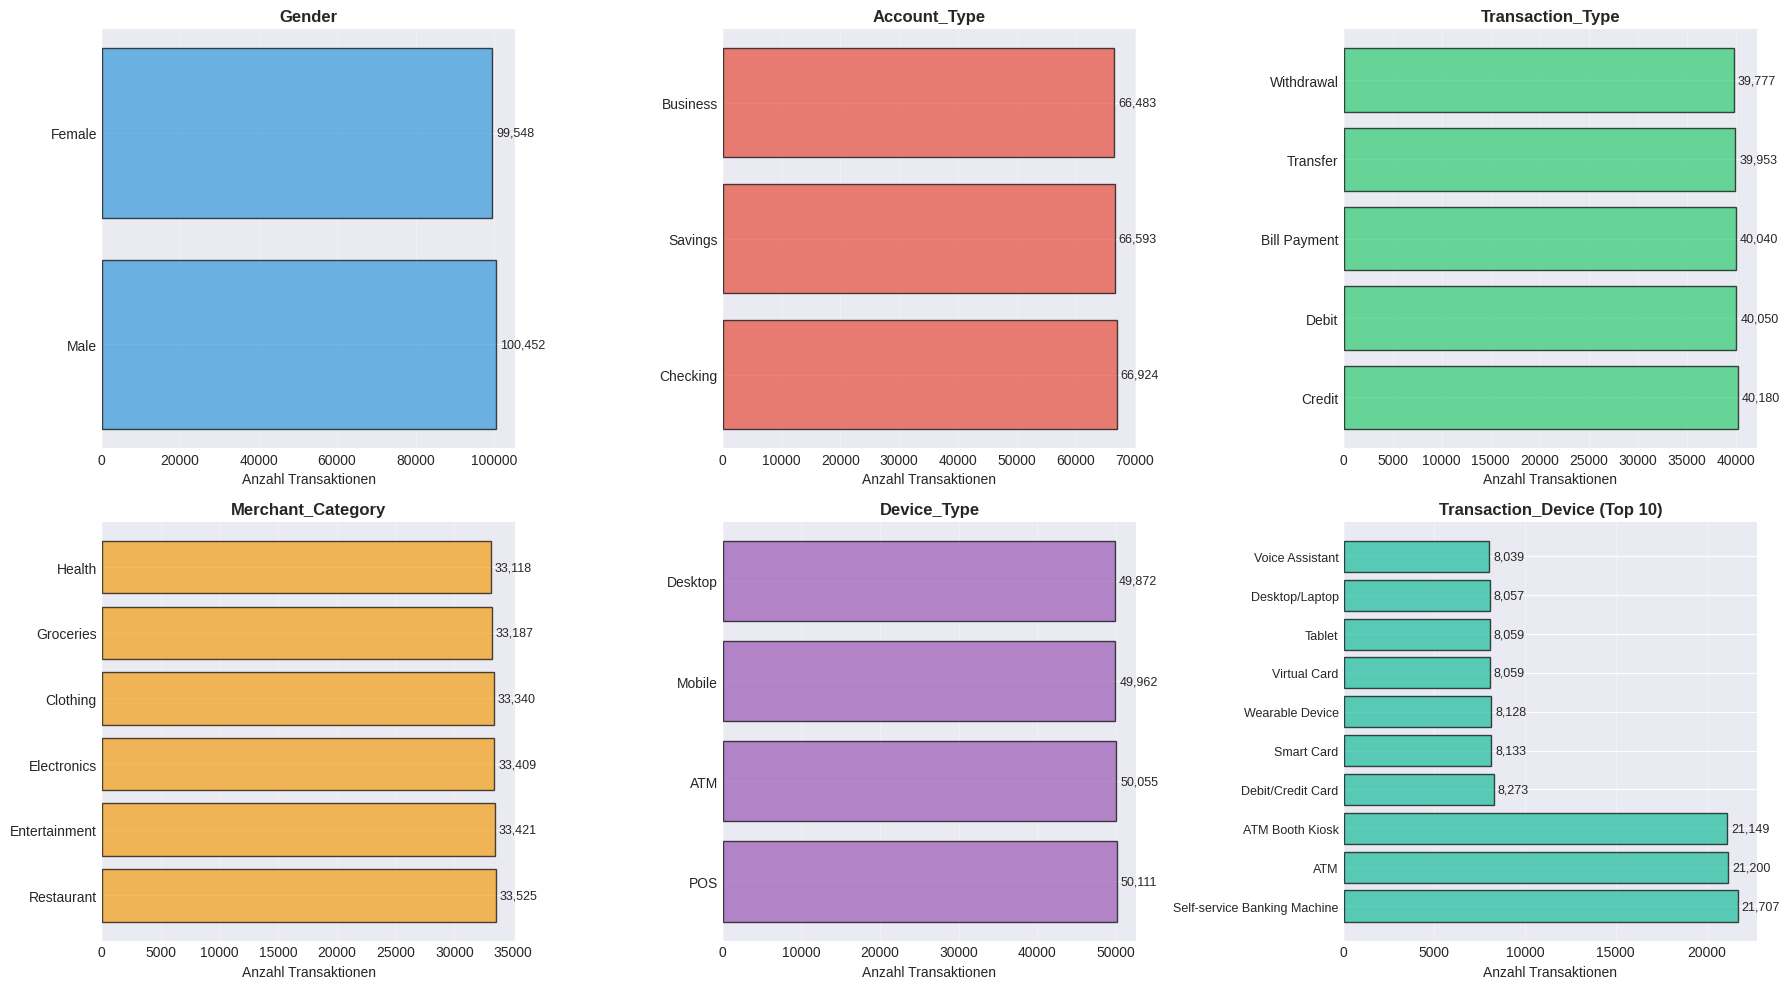

In [17]:
# Visualisierung wichtiger kategorialer Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

features_to_plot = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Device_Type']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, feature in enumerate(features_to_plot):
    data = df_loaded[feature].value_counts().head(10)
    axes[idx].barh(range(len(data)), data.values, color=colors_palette[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_yticks(range(len(data)))
    axes[idx].set_yticklabels(data.index, fontsize=10)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Anzahl Transaktionen', fontsize=10)
    axes[idx].grid(alpha=0.3, axis='x')
    
    # Werte anzeigen
    for i, v in enumerate(data.values):
        axes[idx].text(v + max(data.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

# Transaction_Device (Top 10)
data = df_loaded['Transaction_Device'].value_counts().head(10)
axes[5].barh(range(len(data)), data.values, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[5].set_yticks(range(len(data)))
axes[5].set_yticklabels(data.index, fontsize=9)
axes[5].set_title('Transaction_Device (Top 10)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Anzahl Transaktionen', fontsize=10)
axes[5].grid(alpha=0.3, axis='x')

for i, v in enumerate(data.values):
    axes[5].text(v + max(data.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Fraud-Analyse: Vergleich zwischen legitimen und betrügerischen Transaktionen

Vergleich der Eigenschaften von Betrug vs. legitimen Transaktionen.

In [18]:
# Numerische Features nach Fraud-Status vergleichen
print("=" * 80)
print("VERGLEICH NUMERISCHER FEATURES: BETRUG vs. LEGITIM")
print("=" * 80)

fraud_data = df_loaded[df_loaded['Is_Fraud'] == 1]
legitimate_data = df_loaded[df_loaded['Is_Fraud'] == 0]

comparison_features = ['Transaction_Amount', 'Account_Balance', 'Age']

for feature in comparison_features:
    print(f"\n{feature}:")
    print(f"  Legitim  - Mittelwert: {legitimate_data[feature].mean():10.2f}, Median: {legitimate_data[feature].median():10.2f}")
    print(f"  Betrug   - Mittelwert: {fraud_data[feature].mean():10.2f}, Median: {fraud_data[feature].median():10.2f}")
    
    # Prozentuale Differenz
    mean_diff = ((fraud_data[feature].mean() - legitimate_data[feature].mean()) / legitimate_data[feature].mean()) * 100
    print(f"  Differenz: {mean_diff:+.2f}% (Betrug vs. Legitim)")

VERGLEICH NUMERISCHER FEATURES: BETRUG vs. LEGITIM

Transaction_Amount:
  Legitim  - Mittelwert:   49551.83, Median:   49517.42
  Betrug   - Mittelwert:   49277.93, Median:   49162.94
  Differenz: -0.55% (Betrug vs. Legitim)

Account_Balance:
  Legitim  - Mittelwert:   52437.20, Median:   52373.71
  Betrug   - Mittelwert:   52452.89, Median:   52344.73
  Differenz: +0.03% (Betrug vs. Legitim)

Age:
  Legitim  - Mittelwert:      44.02, Median:      44.00
  Betrug   - Mittelwert:      43.91, Median:      44.00
  Differenz: -0.24% (Betrug vs. Legitim)


/tmp/ipykernel_1600289/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
/tmp/ipykernel_1600289/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
/tmp/ipykernel_1600289/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,


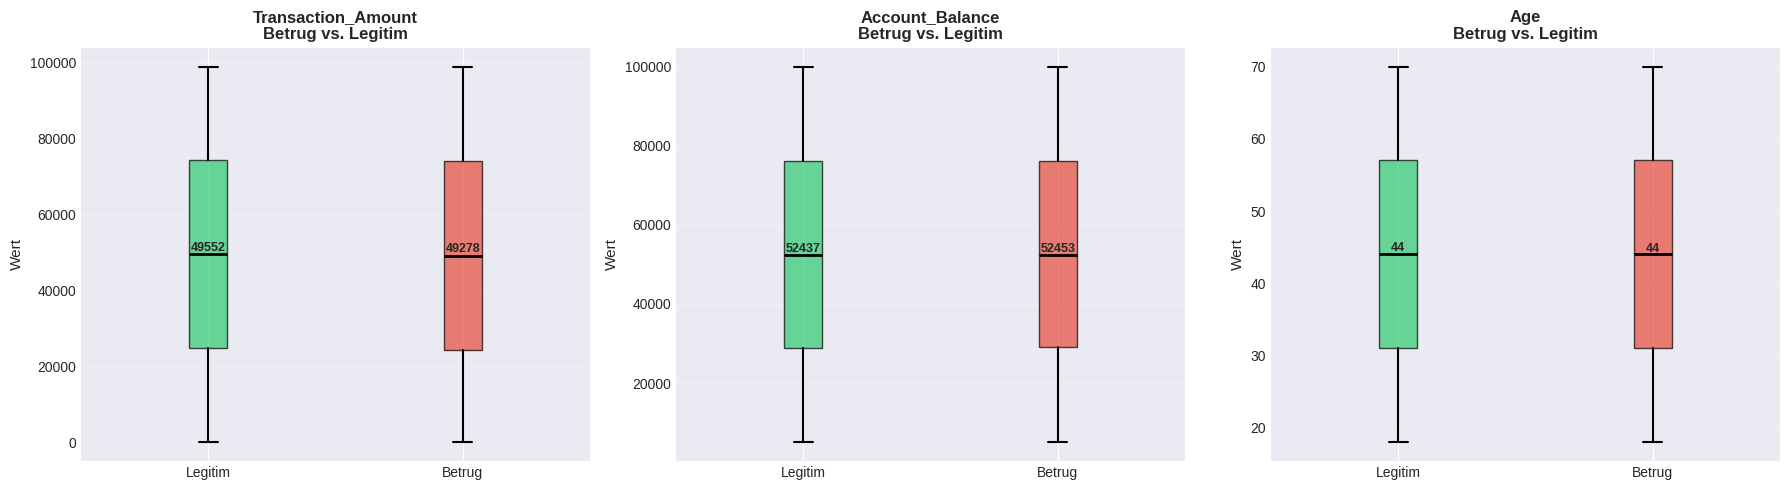

In [19]:
# Visualisierung: Vergleich numerischer Features zwischen Betrug und Legitim
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_features_vis = ['Transaction_Amount', 'Account_Balance', 'Age']
colors = ['#2ecc71', '#e74c3c']

for idx, feature in enumerate(comparison_features_vis):
    # Boxplot für Betrug vs. Legitim
    data_to_plot = [legitimate_data[feature], fraud_data[feature]]
    bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
                            medianprops=dict(color='black', linewidth=2),
                            whiskerprops=dict(linewidth=1.5),
                            capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[idx].set_title(f'{feature}\nBetrug vs. Legitim', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Wert', fontsize=11)
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Mittelwerte anzeigen
    mean_legit = legitimate_data[feature].mean()
    mean_fraud = fraud_data[feature].mean()
    axes[idx].text(1, mean_legit, f'{mean_legit:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[idx].text(2, mean_fraud, f'{mean_fraud:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
# Fraud-Rate nach kategorialen Features
print("=" * 80)
print("FRAUD-RATE NACH KATEGORISCHEN FEATURES")
print("=" * 80)

categorical_features = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                        'Transaction_Device', 'Device_Type']

for feature in categorical_features:
    print(f"\n{feature}:")
    fraud_rate = df_loaded.groupby(feature)['Is_Fraud'].agg(['sum', 'count', 'mean'])
    fraud_rate.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
    fraud_rate['Betrug_Rate'] = fraud_rate['Betrug_Rate'] * 100
    fraud_rate = fraud_rate.sort_values('Betrug_Rate', ascending=False)
    
    print(fraud_rate.head(10).to_string())

FRAUD-RATE NACH KATEGORISCHEN FEATURES

Gender:
        Betrug_Anzahl   Total  Betrug_Rate
Gender                                    
Male             5081  100452     5.058137
Female           5007   99548     5.029734

Account_Type:
              Betrug_Anzahl  Total  Betrug_Rate
Account_Type                                   
Business               3436  66483     5.168238
Savings                3349  66593     5.029057
Checking               3303  66924     4.935449

Transaction_Type:
                  Betrug_Anzahl  Total  Betrug_Rate
Transaction_Type                                   
Transfer                   2073  39953     5.188597
Credit                     2048  40180     5.097063
Debit                      2033  40050     5.076155
Withdrawal                 1961  39777     4.929985
Bill Payment               1973  40040     4.927572

Merchant_Category:
                   Betrug_Anzahl  Total  Betrug_Rate
Merchant_Category                                   
Clothing        

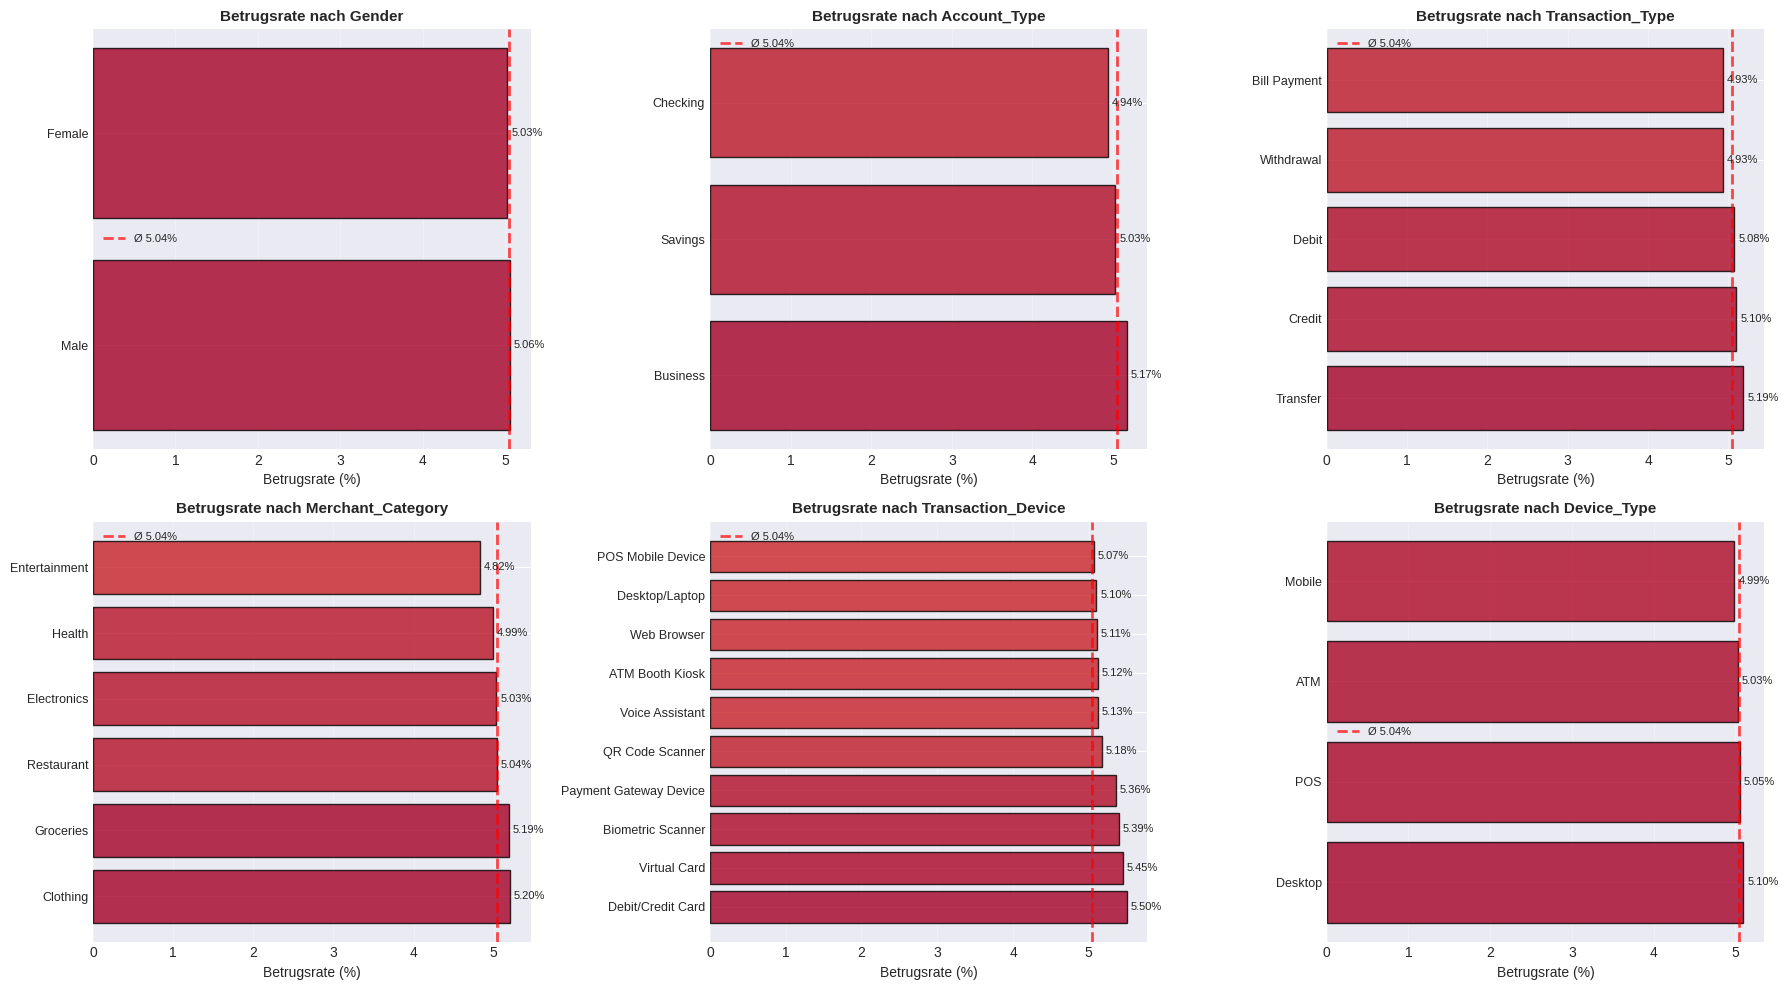

In [21]:
# Visualisierung: Fraud-Rate nach kategorischen Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

categorical_features_vis = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                            'Transaction_Device', 'Device_Type']

for idx, feature in enumerate(categorical_features_vis):
    fraud_rate_data = df_loaded.groupby(feature)['Is_Fraud'].agg(['sum', 'count', 'mean'])
    fraud_rate_data.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
    fraud_rate_data['Betrug_Rate'] = fraud_rate_data['Betrug_Rate'] * 100
    fraud_rate_data = fraud_rate_data.sort_values('Betrug_Rate', ascending=False).head(10)
    
    # Farbverlauf basierend auf Betrugsrate
    colors_grad = plt.cm.RdYlGn_r(fraud_rate_data['Betrug_Rate'] / fraud_rate_data['Betrug_Rate'].max())
    
    axes[idx].barh(range(len(fraud_rate_data)), fraud_rate_data['Betrug_Rate'], 
                   color=colors_grad, edgecolor='black', alpha=0.8)
    axes[idx].set_yticks(range(len(fraud_rate_data)))
    axes[idx].set_yticklabels(fraud_rate_data.index, fontsize=9)
    axes[idx].set_title(f'Betrugsrate nach {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Betrugsrate (%)', fontsize=10)
    axes[idx].grid(alpha=0.3, axis='x')
    
    # Durchschnittliche Betrugsrate als Linie
    avg_fraud_rate = df_loaded['Is_Fraud'].mean() * 100
    axes[idx].axvline(avg_fraud_rate, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Ø {avg_fraud_rate:.2f}%')
    axes[idx].legend(fontsize=8)
    
    # Werte anzeigen
    for i, v in enumerate(fraud_rate_data['Betrug_Rate']):
        axes[idx].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Geografische Analyse

Analyse nach Bundesstaaten und Städten.

In [22]:
# Geografische Verteilung
print("=" * 80)
print("GEOGRAFISCHE VERTEILUNG")
print("=" * 80)

print(f"\nAnzahl eindeutiger Bundesstaaten: {df_loaded['State'].nunique()}")
print(f"Anzahl eindeutiger Städte: {df_loaded['City'].nunique()}")

print("\n--- Top 10 Bundesstaaten nach Transaktionsanzahl ---")
state_counts = df_loaded['State'].value_counts().head(10)
for state, count in state_counts.items():
    print(f"{state:20s}: {count:7,} Transaktionen")

print("\n--- Top 10 Städte nach Transaktionsanzahl ---")
city_counts = df_loaded['City'].value_counts().head(10)
for city, count in city_counts.items():
    print(f"{city:20s}: {count:7,} Transaktionen")

GEOGRAFISCHE VERTEILUNG

Anzahl eindeutiger Bundesstaaten: 34
Anzahl eindeutiger Städte: 145

--- Top 10 Bundesstaaten nach Transaktionsanzahl ---
Nagaland            :   6,031 Transaktionen
Meghalaya           :   6,003 Transaktionen
Uttar Pradesh       :   6,002 Transaktionen
Uttarakhand         :   5,985 Transaktionen
Lakshadweep         :   5,954 Transaktionen
Telangana           :   5,952 Transaktionen
Haryana             :   5,947 Transaktionen
Delhi               :   5,943 Transaktionen
Kerala              :   5,933 Transaktionen
Madhya Pradesh      :   5,928 Transaktionen

--- Top 10 Städte nach Transaktionsanzahl ---
Chandigarh          :   8,135 Transaktionen
Kavaratti           :   5,954 Transaktionen
Udaipur             :   2,681 Transaktionen
Daman               :   2,022 Transaktionen
Car Nicobar         :   1,956 Transaktionen
Port Blair          :   1,950 Transaktionen
Diglipur            :   1,926 Transaktionen
Diu                 :   1,919 Transaktionen
Silvassa      

In [23]:
# Fraud-Rate nach Bundesstaat
print("=" * 80)
print("FRAUD-RATE NACH BUNDESSTAAT")
print("=" * 80)

state_fraud = df_loaded.groupby('State')['Is_Fraud'].agg(['sum', 'count', 'mean'])
state_fraud.columns = ['Betrug_Anzahl', 'Total_Transaktionen', 'Betrug_Rate']
state_fraud['Betrug_Rate'] = state_fraud['Betrug_Rate'] * 100
state_fraud = state_fraud.sort_values('Betrug_Rate', ascending=False)

print("\nTop 10 Bundesstaaten mit höchster Betrugsrate:")
print(state_fraud.head(10).to_string())

print("\n\nTop 10 Bundesstaaten mit niedrigster Betrugsrate:")
print(state_fraud.tail(10).to_string())

FRAUD-RATE NACH BUNDESSTAAT

Top 10 Bundesstaaten mit höchster Betrugsrate:
                Betrug_Anzahl  Total_Transaktionen  Betrug_Rate
State                                                          
Tamil Nadu                328                 5841     5.615477
Lakshadweep               332                 5954     5.576083
Sikkim                    312                 5793     5.385810
Uttarakhand               319                 5985     5.329992
West Bengal               311                 5851     5.315331
Madhya Pradesh            315                 5928     5.313765
Mizoram                   312                 5892     5.295316
Telangana                 315                 5952     5.292339
Tripura                   308                 5869     5.247913
Karnataka                 303                 5775     5.246753


Top 10 Bundesstaaten mit niedrigster Betrugsrate:
                             Betrug_Anzahl  Total_Transaktionen  Betrug_Rate
State                      

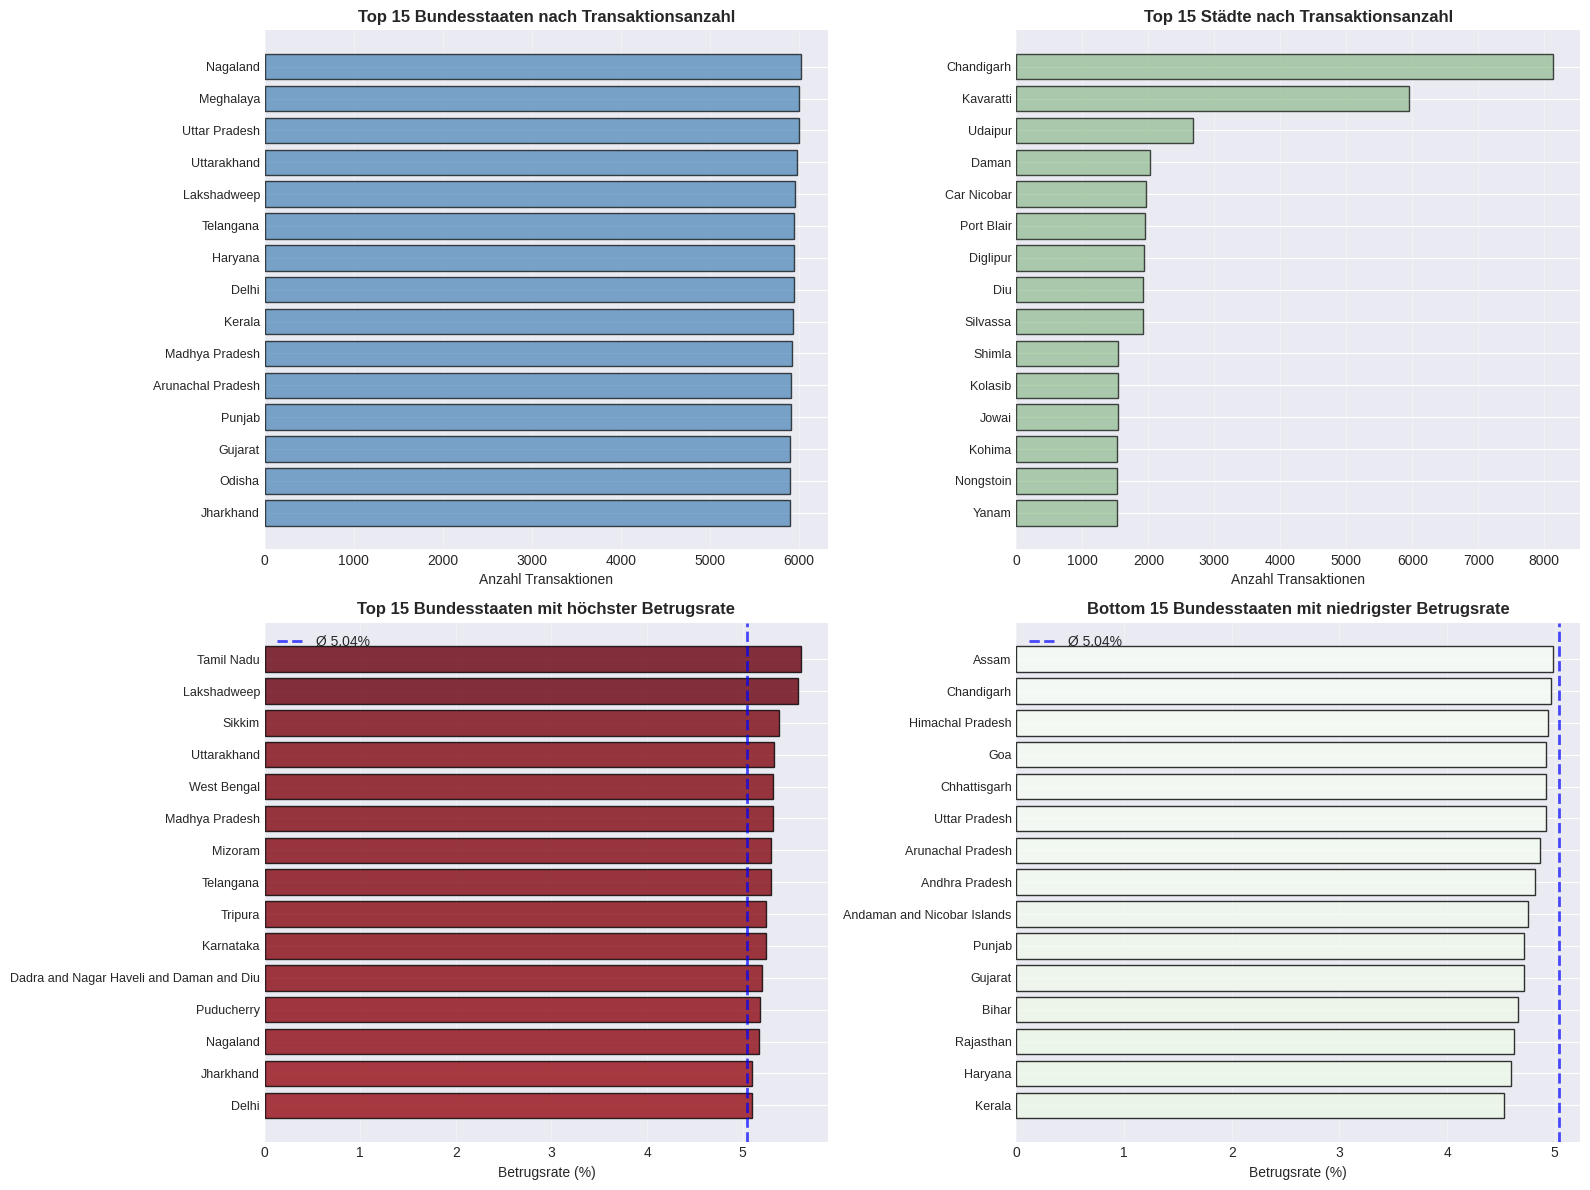

In [24]:
# Visualisierung: Geografische Verteilung und Betrugsraten
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 15 Bundesstaaten nach Transaktionsanzahl
state_counts_top = df_loaded['State'].value_counts().head(15)
axes[0, 0].barh(range(len(state_counts_top)), state_counts_top.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_yticks(range(len(state_counts_top)))
axes[0, 0].set_yticklabels(state_counts_top.index, fontsize=9)
axes[0, 0].set_title('Top 15 Bundesstaaten nach Transaktionsanzahl', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Anzahl Transaktionen', fontsize=10)
axes[0, 0].grid(alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# Top 15 Städte nach Transaktionsanzahl
city_counts_top = df_loaded['City'].value_counts().head(15)
axes[0, 1].barh(range(len(city_counts_top)), city_counts_top.values, color='darkseagreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_yticks(range(len(city_counts_top)))
axes[0, 1].set_yticklabels(city_counts_top.index, fontsize=9)
axes[0, 1].set_title('Top 15 Städte nach Transaktionsanzahl', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Anzahl Transaktionen', fontsize=10)
axes[0, 1].grid(alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# Top 15 Bundesstaaten mit höchster Betrugsrate
state_fraud_top = state_fraud.head(15)
colors_grad = plt.cm.Reds(state_fraud_top['Betrug_Rate'] / state_fraud_top['Betrug_Rate'].max())
axes[1, 0].barh(range(len(state_fraud_top)), state_fraud_top['Betrug_Rate'], 
                color=colors_grad, edgecolor='black', alpha=0.8)
axes[1, 0].set_yticks(range(len(state_fraud_top)))
axes[1, 0].set_yticklabels(state_fraud_top.index, fontsize=9)
axes[1, 0].set_title('Top 15 Bundesstaaten mit höchster Betrugsrate', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Betrugsrate (%)', fontsize=10)
axes[1, 0].grid(alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# Durchschnitt anzeigen
avg_rate = df_loaded['Is_Fraud'].mean() * 100
axes[1, 0].axvline(avg_rate, color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Ø {avg_rate:.2f}%')
axes[1, 0].legend()

# Bottom 15 Bundesstaaten mit niedrigster Betrugsrate
state_fraud_bottom = state_fraud.tail(15)
colors_grad = plt.cm.Greens(1 - state_fraud_bottom['Betrug_Rate'] / state_fraud_bottom['Betrug_Rate'].max())
axes[1, 1].barh(range(len(state_fraud_bottom)), state_fraud_bottom['Betrug_Rate'], 
                color=colors_grad, edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(range(len(state_fraud_bottom)))
axes[1, 1].set_yticklabels(state_fraud_bottom.index, fontsize=9)
axes[1, 1].set_title('Bottom 15 Bundesstaaten mit niedrigster Betrugsrate', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Betrugsrate (%)', fontsize=10)
axes[1, 1].grid(alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()
axes[1, 1].axvline(avg_rate, color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Ø {avg_rate:.2f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Zeitliche Analyse

Analyse der zeitlichen Muster in den Transaktionen.

In [25]:
# Zeitliche Muster untersuchen
print("=" * 80)
print("ZEITLICHE ANALYSE")
print("=" * 80)

# Überprüfen, welche Datumsformat verwendet wird
print("\nBeispiel Transaction_Date Werte:")
print(df_loaded['Transaction_Date'].head())
print(f"\nDatentyp: {df_loaded['Transaction_Date'].dtype}")

print("\nBeispiel Transaction_Time Werte:")
print(df_loaded['Transaction_Time'].head())
print(f"\nDatentyp: {df_loaded['Transaction_Time'].dtype}")

# Eindeutige Datumswerte
print(f"\nAnzahl eindeutiger Datumswerte: {df_loaded['Transaction_Date'].nunique()}")
print(f"Datum Bereich: {df_loaded['Transaction_Date'].min()} bis {df_loaded['Transaction_Date'].max()}")

ZEITLICHE ANALYSE

Beispiel Transaction_Date Werte:
0    23-01-2025
1    11-01-2025
2    25-01-2025
3    19-01-2025
4    30-01-2025
Name: Transaction_Date, dtype: object

Datentyp: object

Beispiel Transaction_Time Werte:
0    16:04:07
1    17:14:53
2    03:09:52
3    12:27:02
4    18:30:46
Name: Transaction_Time, dtype: object

Datentyp: object

Anzahl eindeutiger Datumswerte: 31
Datum Bereich: 01-01-2025 bis 31-01-2025


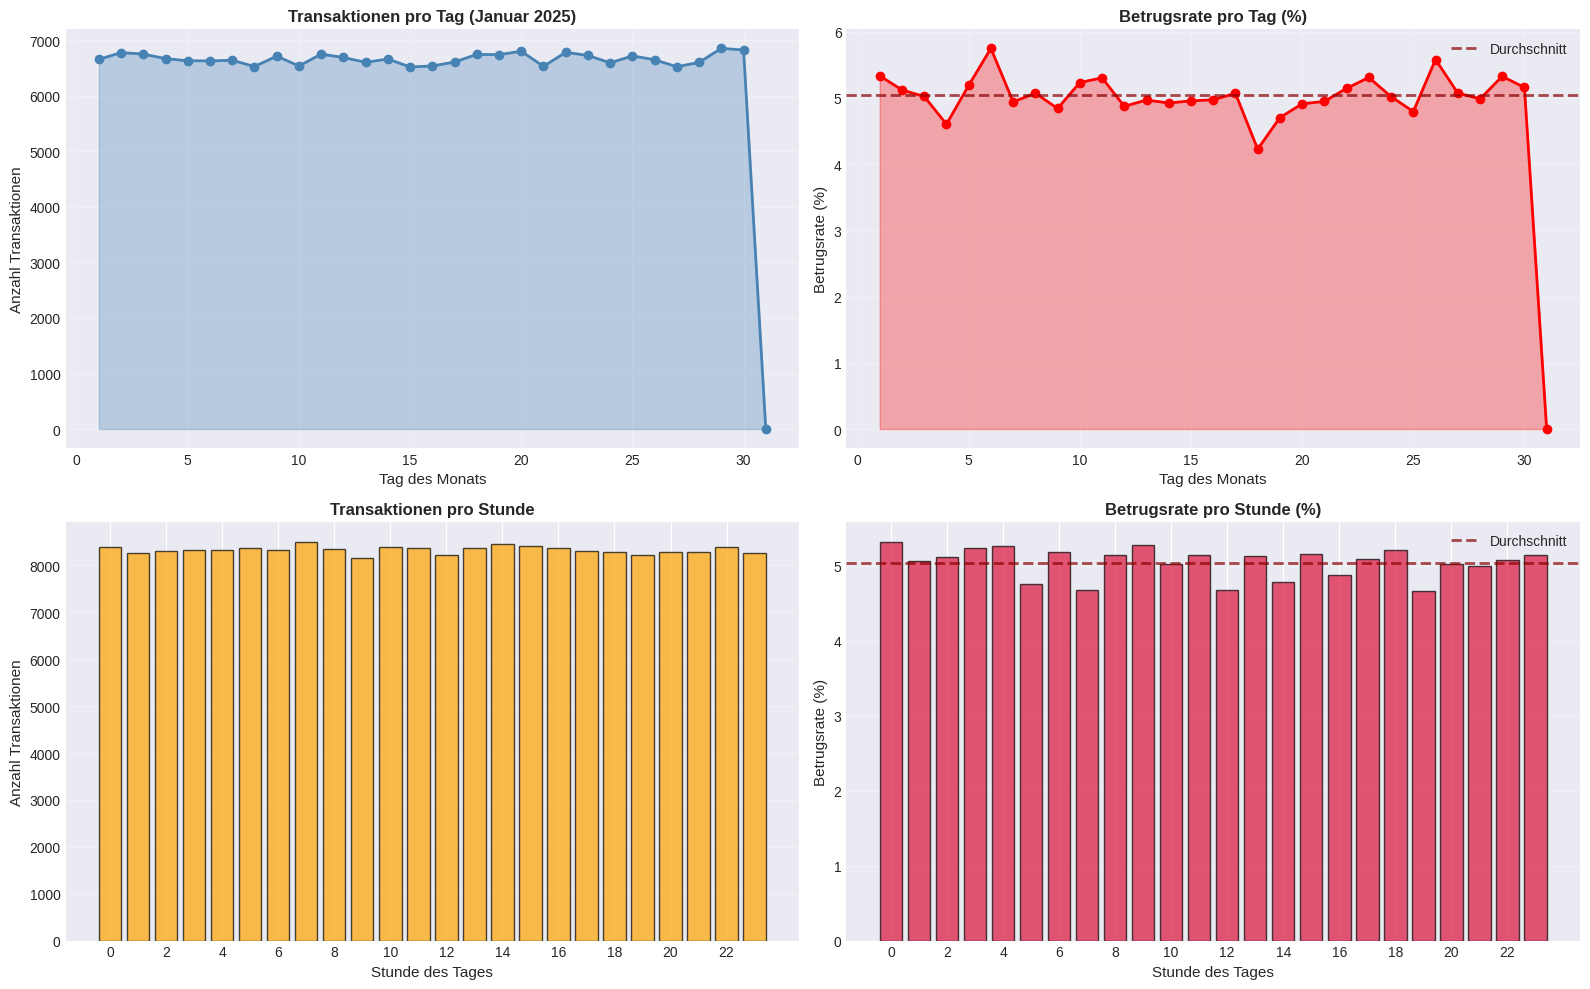


✓ Zeitliche Muster analysiert


In [ ]:
# Zeitliche Analysen mit Visualisierung
# Datum zu datetime konvertieren für bessere Analyse
df_loaded['Transaction_Date_parsed'] = pd.to_datetime(df_loaded['Transaction_Date'], format='%d-%m-%Y')
df_loaded['Day'] = df_loaded['Transaction_Date_parsed'].dt.day
df_loaded['Weekday'] = df_loaded['Transaction_Date_parsed'].dt.day_name()

# Uhrzeit extrahieren (Stunde)
df_loaded['Hour'] = pd.to_datetime(df_loaded['Transaction_Time'], format='%H:%M:%S').dt.hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Transaktionen pro Tag
daily_trans = df_loaded.groupby('Day').size()
axes[0, 0].plot(daily_trans.index, daily_trans.values, marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 0].set_title('Transaktionen pro Tag (Januar 2025)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tag des Monats', fontsize=11)
axes[0, 0].set_ylabel('Anzahl Transaktionen', fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].fill_between(daily_trans.index, daily_trans.values, alpha=0.3, color='steelblue')

# Betrugsrate pro Tag
daily_fraud = df_loaded.groupby('Day')['Is_Fraud'].mean() * 100
axes[0, 1].plot(daily_fraud.index, daily_fraud.values, marker='o', linewidth=2, markersize=6, color='red')
axes[0, 1].axhline(df_loaded['Is_Fraud'].mean() * 100, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='Durchschnitt')
axes[0, 1].set_title('Betrugsrate pro Tag (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tag des Monats', fontsize=11)
axes[0, 1].set_ylabel('Betrugsrate (%)', fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()
axes[0, 1].fill_between(daily_fraud.index, daily_fraud.values, alpha=0.3, color='red')

# Transaktionen pro Stunde
hourly_trans = df_loaded.groupby('Hour').size()
axes[1, 0].bar(hourly_trans.index, hourly_trans.values, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Transaktionen pro Stunde', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Stunde des Tages', fontsize=11)
axes[1, 0].set_ylabel('Anzahl Transaktionen', fontsize=11)
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, 24, 2))

# Betrugsrate pro Stunde
hourly_fraud = df_loaded.groupby('Hour')['Is_Fraud'].mean() * 100
axes[1, 1].bar(hourly_fraud.index, hourly_fraud.values, color='crimson', edgecolor='black', alpha=0.7)
axes[1, 1].axhline(df_loaded['Is_Fraud'].mean() * 100, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='Durchschnitt')
axes[1, 1].set_title('Betrugsrate pro Stunde (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Stunde des Tages', fontsize=11)
axes[1, 1].set_ylabel('Betrugsrate (%)', fontsize=11)
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Spezielle Analysen

Weitere interessante Muster und Auffälligkeiten.

In [27]:
# Analyse: Transaktionsbetrag vs. Kontostand
print("=" * 80)
print("VERHÄLTNIS: TRANSAKTIONSBETRAG ZU KONTOSTAND")
print("=" * 80)

# Berechne Verhältnis
df_loaded_copy = df_loaded.copy()
df_loaded_copy['Amount_to_Balance_Ratio'] = df_loaded_copy['Transaction_Amount'] / df_loaded_copy['Account_Balance']

# Entferne unendliche Werte (wenn Kontostand 0 ist)
df_loaded_copy = df_loaded_copy[~df_loaded_copy['Amount_to_Balance_Ratio'].isin([float('inf'), -float('inf')])]

print(f"\nVerhältnis Statistiken:")
print(f"Mittelwert: {df_loaded_copy['Amount_to_Balance_Ratio'].mean():.4f}")
print(f"Median: {df_loaded_copy['Amount_to_Balance_Ratio'].median():.4f}")

# Vergleich zwischen Betrug und Legitim
fraud_ratio = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 1]['Amount_to_Balance_Ratio']
legit_ratio = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 0]['Amount_to_Balance_Ratio']

print(f"\nBetrug - Verhältnis Mittelwert: {fraud_ratio.mean():.4f}")
print(f"Legitim - Verhältnis Mittelwert: {legit_ratio.mean():.4f}")

# Transaktionen die mehr als 50% des Kontostands ausmachen
high_ratio = (df_loaded_copy['Amount_to_Balance_Ratio'] > 0.5).sum()
print(f"\nTransaktionen > 50% des Kontostands: {high_ratio:,} ({high_ratio/len(df_loaded_copy)*100:.2f}%)")

VERHÄLTNIS: TRANSAKTIONSBETRAG ZU KONTOSTAND



Verhältnis Statistiken:
Mittelwert: 1.5663
Median: 0.9441

Betrug - Verhältnis Mittelwert: 1.5642
Legitim - Verhältnis Mittelwert: 1.5664

Transaktionen > 50% des Kontostands: 146,835 (73.42%)


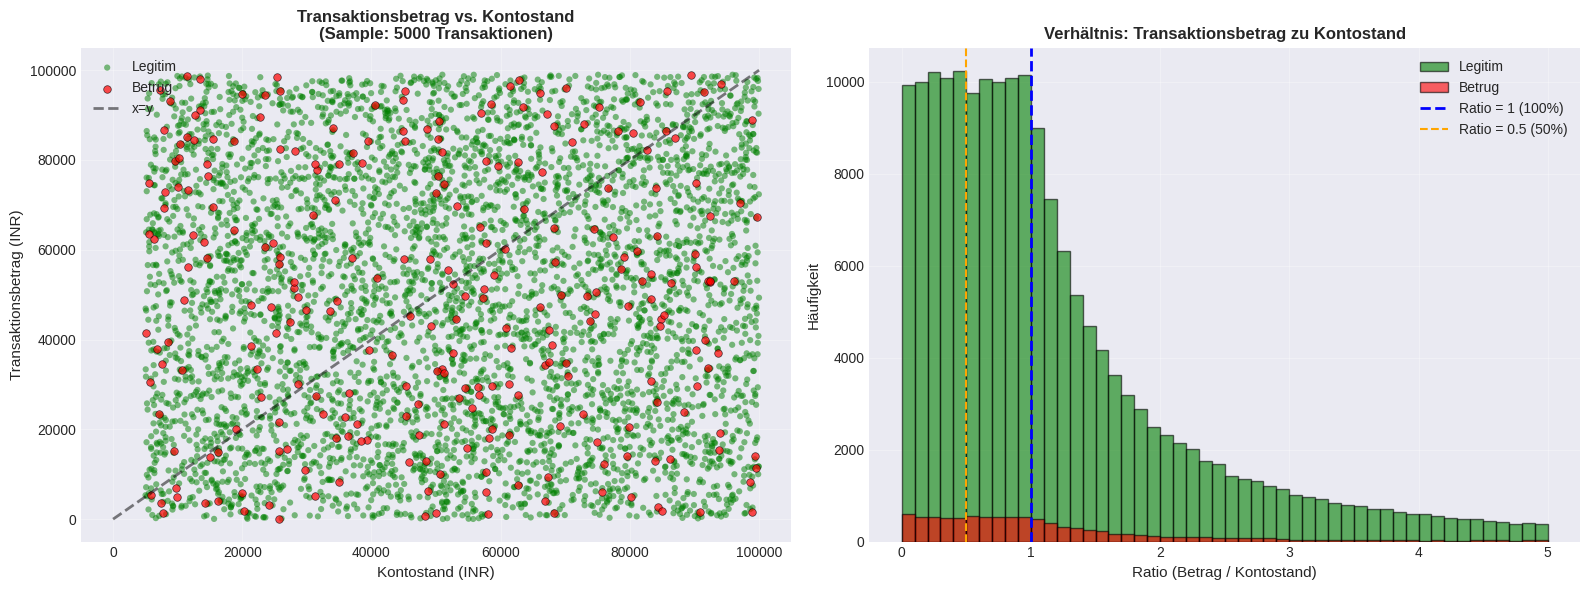

In [28]:
# Visualisierung: Transaktionsbetrag vs. Kontostand
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot: Transaktionsbetrag vs. Kontostand (Sample für Performance)
sample_size = 5000
sample_df = df_loaded.sample(n=min(sample_size, len(df_loaded)), random_state=42)

# Legitime Transaktionen
legit_sample = sample_df[sample_df['Is_Fraud'] == 0]
fraud_sample = sample_df[sample_df['Is_Fraud'] == 1]

axes[0].scatter(legit_sample['Account_Balance'], legit_sample['Transaction_Amount'], 
                alpha=0.5, s=20, color='green', label='Legitim', edgecolors='none')
axes[0].scatter(fraud_sample['Account_Balance'], fraud_sample['Transaction_Amount'], 
                alpha=0.7, s=30, color='red', label='Betrug', edgecolors='black', linewidths=0.5)
axes[0].plot([0, 100000], [0, 100000], 'k--', alpha=0.5, linewidth=2, label='x=y')
axes[0].set_title('Transaktionsbetrag vs. Kontostand\n(Sample: 5000 Transaktionen)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kontostand (INR)', fontsize=11)
axes[0].set_ylabel('Transaktionsbetrag (INR)', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogramm: Verhältnis Transaktionsbetrag zu Kontostand
ratio_legit = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 0]['Amount_to_Balance_Ratio']
ratio_fraud = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 1]['Amount_to_Balance_Ratio']

axes[1].hist(ratio_legit, bins=50, alpha=0.6, color='green', label='Legitim', edgecolor='black', range=(0, 5))
axes[1].hist(ratio_fraud, bins=50, alpha=0.6, color='red', label='Betrug', edgecolor='black', range=(0, 5))
axes[1].axvline(1, color='blue', linestyle='--', linewidth=2, label='Ratio = 1 (100%)')
axes[1].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Ratio = 0.5 (50%)')
axes[1].set_title('Verhältnis: Transaktionsbetrag zu Kontostand', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ratio (Betrag / Kontostand)', fontsize=11)
axes[1].set_ylabel('Häufigkeit', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Analyse: Transaktionen pro Kunde
print("=" * 80)
print("TRANSAKTIONEN PRO KUNDE")
print("=" * 80)

transactions_per_customer = df_loaded.groupby('Customer_ID').size()

print(f"\nStatistiken:")
print(f"Mittelwert: {transactions_per_customer.mean():.2f} Transaktionen pro Kunde")
print(f"Median: {transactions_per_customer.median():.0f} Transaktionen pro Kunde")
print(f"Maximum: {transactions_per_customer.max()} Transaktionen")
print(f"Minimum: {transactions_per_customer.min()} Transaktion")

print(f"\nVerteilung:")
print(transactions_per_customer.value_counts().sort_index().head(10))

# Kunden mit den meisten Transaktionen
print(f"\nTop 10 Kunden mit den meisten Transaktionen:")
top_customers = transactions_per_customer.nlargest(10)
for idx, (customer_id, count) in enumerate(top_customers.items(), 1):
    fraud_count = df_loaded[df_loaded['Customer_ID'] == customer_id]['Is_Fraud'].sum()
    print(f"  {idx:2d}. {count:3d} Transaktionen (davon {fraud_count} Betrug)")

TRANSAKTIONEN PRO KUNDE

Statistiken:
Mittelwert: 1.00 Transaktionen pro Kunde
Median: 1 Transaktionen pro Kunde
Maximum: 1 Transaktionen
Minimum: 1 Transaktion

Verteilung:
1    200000
Name: count, dtype: int64

Top 10 Kunden mit den meisten Transaktionen:
   1.   1 Transaktionen (davon 0 Betrug)
   2.   1 Transaktionen (davon 0 Betrug)
   3.   1 Transaktionen (davon 0 Betrug)
   4.   1 Transaktionen (davon 0 Betrug)
   5.   1 Transaktionen (davon 0 Betrug)
   6.   1 Transaktionen (davon 0 Betrug)
   7.   1 Transaktionen (davon 0 Betrug)
   8.   1 Transaktionen (davon 0 Betrug)
   9.   1 Transaktionen (davon 0 Betrug)
  10.   1 Transaktionen (davon 0 Betrug)


In [24]:
# Merchant-Analyse
print("=" * 80)
print("MERCHANT-ANALYSE")
print("=" * 80)

print(f"\nAnzahl eindeutiger Merchants: {df_loaded['Merchant_ID'].nunique():,}")

# Transaktionen pro Merchant
transactions_per_merchant = df_loaded.groupby('Merchant_ID').size()
print(f"\nTransaktionen pro Merchant:")
print(f"Mittelwert: {transactions_per_merchant.mean():.2f}")
print(f"Median: {transactions_per_merchant.median():.0f}")
print(f"Maximum: {transactions_per_merchant.max()}")

# Merchants mit höchster Betrugsrate
merchant_fraud = df_loaded.groupby('Merchant_ID')['Is_Fraud'].agg(['sum', 'count', 'mean'])
merchant_fraud.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
merchant_fraud['Betrug_Rate'] = merchant_fraud['Betrug_Rate'] * 100

# Nur Merchants mit mindestens 10 Transaktionen
merchant_fraud_filtered = merchant_fraud[merchant_fraud['Total'] >= 10].sort_values('Betrug_Rate', ascending=False)

print(f"\nTop 10 Merchants mit höchster Betrugsrate (mind. 10 Transaktionen):")
print(merchant_fraud_filtered.head(10).to_string())

MERCHANT-ANALYSE

Anzahl eindeutiger Merchants: 200,000

Transaktionen pro Merchant:
Mittelwert: 1.00
Median: 1
Maximum: 1

Top 10 Merchants mit höchster Betrugsrate (mind. 10 Transaktionen):
Empty DataFrame
Columns: [Betrug_Anzahl, Total, Betrug_Rate]
Index: []


## 10. Wichtigste Erkenntnisse und Beobachtungen

**Kurze Zusammenfassung auf Basis der Analyse --> ggf. könnten wir das dann ja zusammenfassend so in die Arbeit mit aufnehmen?**

### Datensatzstruktur
- **Sauberer Datensatz**: Keine fehlenden Werte, keine Duplikate (das ist doch gut!)
- **Ausgewogene Features**: Gute Mischung aus numerischen und kategorialen Variablen
- **Eindeutige Transaktionen**: Jede Transaktion hat einen eindeutigen Kunden und Merchant (keine wiederkehrenden Kunden --> irgendwie komisch, aber ist halt so im Datensatz)

### Fraud-Charakteristiken
- **Klassenungleichgewicht**: Stark unbalanciert (ungefähr 18:1 Ratio) --> ggf. müssten wir hier nachsteuern mit synthetischen Daten oder so
- **Numerische Unterschiede**: Betrug und legitime Transaktionen haben sehr ähnliche numerische Eigenschaften (Betrag, Kontostand, Alter)
- **Kategorische Muster**: 
  - Business-Konten haben etwas höhere Betrugsraten (5.17%)
  - Debit/Credit Card als Transaktionsgerät zeigt höchste Betrugsrate (5.50%)
  - Clothing- und Groceries-Kategorien haben leicht erhöhte Raten

### Geografische Verteilung --> Nur hier kann dann dauerhaft auch das Modell angewandt werden
- **Regional unterschiedlich**: Tamil Nadu (5.62%) und Lakshadweep (5.58%) haben die höchsten Betrugsraten
- **Kerala am sichersten**: Mit 4.53% die niedrigste Betrugsrate

### Zeitliche Muster --> Zeitreihenanalyse wohl nicht so gut möglich, da nur eine Transaktion pro Kunde
- **Einmonatiger Datensatz**: Januar 2025 (01.01. bis 31.01.2025)
- **Vollständige Zeitstempel**: Transaction_Date und Transaction_Time für zeitliche Analysen verfügbar

### Besondere Beobachtungen
1. **Jeder Kunde hat nur eine Transaktion** - Dies ist untypisch für reale Bankdaten
2. **Jeder Merchant ist eindeutig** - Ebenfalls ungewöhnlich, da Merchants normalerweise mehrere Transaktionen haben
3. **Betrugsmerkmale sind subtil** - Keine offensichtlichen Unterschiede in numerischen Features zwischen Betrug und Legitim
4. **Hoher Transaktionsbetrag relativ zum Kontostand** - 73% der Transaktionen machen >50% des Kontostands aus

### Implikationen für Modellierung
- **Umgang mit Unbalance nötig**: SMOTE, Undersampling oder Class Weights
- **Feature Engineering wichtig**: Kategoriale Features könnten informativer sein als numerische
- **Keine Zeitreihen-Features**: Da jeder Kunde nur eine Transaktion hat
- **Fokus auf kategoriale Muster**: Device Type, Merchant Category, Transaction Type könnten wichtige Prädiktoren sein